In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from src.forecaster import Forecaster
from src.models import LSTMHistoric, LSTMEncoderDecoder
from src.data import DataSource, TimeSeriesData
from src.utils.scores_and_losses import MAE, NSE, RMSE, DILATE


In [2]:
HISTORIC_COLS = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
FUTURE_COLS   = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
TARGET_COL    = 'target'
HORIZON       = 7
SEQ_LEN       = 30
NODATA_VALUES = [-999]

train_source = DataSource(
    csv='../data/data.csv',
    start='1980-01-01',
    end='2004-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
val_source = DataSource(
    csv='../data/data.csv',
    start='2005-01-01',
    end='2009-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
test_source = DataSource(
    csv='../data/data.csv',
    start='2010-01-01',
    end='2014-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)

train_data = TimeSeriesData([train_source])
val_data = TimeSeriesData([val_source])
test_data = TimeSeriesData([test_source])


In [3]:
fc = Forecaster(
    model=LSTMHistoric(hidden_size=28, num_layers=1, dropout_rate=0.0),
    name='LSTMHistoric_test',
    training_data=train_data,
    validation_data=val_data,
    historic_cols=HISTORIC_COLS,
    # future_cols=FUTURE_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss=MAE(),
    validation_score=NSE(),
    validation_logging_criteria=[RMSE()],
    minimize_validation_score=False,
    save_path='../models',
    batch_size=256,
    number_of_epochs=15,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

print(f'LSTMHistoric parameters: {fc.compute_number_of_parameters()}')


LSTMHistoric parameters: 4123


In [4]:
fc.fit()


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_1.pt
Epoch 1/15  train_loss=0.6747  val_loss=0.5807  val_score=0.0159  best=0.0159


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_2.pt
Epoch 2/15  train_loss=0.5158  val_loss=0.4355  val_score=0.1834  best=0.1834


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_3.pt
Epoch 3/15  train_loss=0.3998  val_loss=0.3546  val_score=0.4393  best=0.4393


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_4.pt
Epoch 4/15  train_loss=0.3099  val_loss=0.2994  val_score=0.6127  best=0.6127


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_5.pt
Epoch 5/15  train_loss=0.2693  val_loss=0.2792  val_score=0.6768  best=0.6768


...

Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_11.pt
Epoch 11/15  train_loss=0.2221  val_loss=0.2424  val_score=0.7586  best=0.7586


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_12.pt
Epoch 12/15  train_loss=0.2222  val_loss=0.2420  val_score=0.7615  best=0.7615


Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_13.pt
Epoch 13/15  train_loss=0.2183  val_loss=0.2449  val_score=0.7506  best=0.7615


Best model saved → ../models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_14.pt
Epoch 14/15  train_loss=0.2184  val_loss=0.2395  val_score=0.7710  best=0.7710


Checkpoint saved  → ../models/LSTMHistoric_test/model_LSTMHistoric_test_epoch_15.pt
Epoch 15/15  train_loss=0.2160  val_loss=0.2385  val_score=0.7630  best=0.7710


In [5]:
import matplotlib.pyplot as plt
from src.data.timeseries_dataset import TimeSeriesDataset
from src.data.normalization import _read_1d_df

# predictions via predict() itself (returns a plain numpy array, already denormalized/CPU)
preds = fc.predict(test_data, batch_size=256)
y_pred = preds.squeeze(-1)  # (n_windows, horizon)

# true values + dates: target_col doesn't affect which windows get built (only x_h/x_f NaN
# does), so this dataset covers the exact same windows as predict()'s internal one — it's
# only built here to read off the (source_idx, t) index for alignment, not to run the model
test_ds = TimeSeriesDataset(
    test_data,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc.norm_stats,
    target_col=TARGET_COL,
)
test_df = _read_1d_df(test_source)
t_values = test_ds.window_index[:, 1]
y_true = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values])

def lead_dates(lead):
    return test_df.index[t_values + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true.shape[0]} windows over a {y_true.shape[1]}-day horizon on test_source')


Evaluated 1789 windows over a 7-day horizon on test_source


In [6]:
fc2 = Forecaster(
    model=LSTMEncoderDecoder(hidden_size=16, num_layers=1, dropout_rate=0.0, encoder_downscale_layer_size=16),
    name='LSTMEncoderDecoder_test',
    training_data=train_data,
    validation_data=val_data,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss=MAE(),
    validation_score=NSE(),
    validation_logging_criteria=[RMSE()],
    minimize_validation_score=False,
    save_path='../models',
    batch_size=256,
    number_of_epochs=15,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

print(f'LSTMEncoderDecoder parameters: {fc2.compute_number_of_parameters()}')


LSTMEncoderDecoder parameters: 4257


In [7]:
fc2.fit()


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_1.pt
Epoch 1/15  train_loss=0.7215  val_loss=0.5949  val_score=0.0861  best=0.0861


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_2.pt
Epoch 2/15  train_loss=0.5271  val_loss=0.4667  val_score=0.1474  best=0.1474


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_3.pt
Epoch 3/15  train_loss=0.4002  val_loss=0.3208  val_score=0.5122  best=0.5122


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_4.pt
Epoch 4/15  train_loss=0.2902  val_loss=0.2842  val_score=0.6422  best=0.6422


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_5.pt
Epoch 5/15  train_loss=0.2606  val_loss=0.2503  val_score=0.7150  best=0.7150


...

Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_11.pt
Epoch 11/15  train_loss=0.1904  val_loss=0.2122  val_score=0.8157  best=0.8175


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_12.pt
Epoch 12/15  train_loss=0.1859  val_loss=0.2069  val_score=0.8200  best=0.8200


Best model saved → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_13.pt
Epoch 13/15  train_loss=0.1841  val_loss=0.2095  val_score=0.8295  best=0.8295


Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_14.pt
Epoch 14/15  train_loss=0.1789  val_loss=0.2127  val_score=0.8072  best=0.8295


Checkpoint saved  → ../models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_epoch_15.pt
Epoch 15/15  train_loss=0.1760  val_loss=0.2122  val_score=0.8278  best=0.8295


In [8]:
preds2 = fc2.predict(test_data, batch_size=256)
y_pred2 = preds2.squeeze(-1)  # (n_windows, horizon)

# same pattern as fc's eval cell above — small TimeSeriesDataset built with fc2's own
# future_cols, purely for window/date alignment via window_index, not for running the model
test_ds2 = TimeSeriesDataset(
    test_data,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc2.norm_stats,
    target_col=TARGET_COL,
)
t_values2 = test_ds2.window_index[:, 1]
y_true2 = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values2])

def lead_dates2(lead):
    return test_df.index[t_values2 + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true2.shape[0]} windows over a {y_true2.shape[1]}-day horizon on test_source (LSTMEncoderDecoder)')


Evaluated 1789 windows over a 7-day horizon on test_source (LSTMEncoderDecoder)


In [9]:
fc3 = Forecaster(
    model=LSTMHistoric(hidden_size=28, num_layers=1, dropout_rate=0.0),
    name='LSTMHistoric_dilate_test',
    training_data=train_data,
    validation_data=val_data,
    historic_cols=HISTORIC_COLS,
    # future_cols=FUTURE_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss=DILATE(),
    validation_score=NSE(),
    validation_logging_criteria=[RMSE()],
    minimize_validation_score=False,
    save_path='../models',
    batch_size=256,
    number_of_epochs=15,
    save_weights_every_n_epochs=1,
)

print(f'LSTMHistoric (DILATE) parameters: {fc3.compute_number_of_parameters()}')


LSTMHistoric (DILATE) parameters: 4123


In [10]:
fc3.fit()


Best model saved → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_1.pt
Epoch 1/15  train_loss=3.4855  val_loss=3.5643  val_score=0.0579  best=0.0579


Best model saved → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_2.pt
Epoch 2/15  train_loss=2.8354  val_loss=2.0357  val_score=0.4771  best=0.4771


Best model saved → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_3.pt
Epoch 3/15  train_loss=1.4635  val_loss=1.2186  val_score=0.6922  best=0.6922


Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_4.pt
Epoch 4/15  train_loss=1.1665  val_loss=1.2555  val_score=0.6772  best=0.6922


Best model saved → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_5.pt
Epoch 5/15  train_loss=1.0241  val_loss=1.1057  val_score=0.7163  best=0.7163


...

Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_11.pt
Epoch 11/15  train_loss=0.7789  val_loss=0.9385  val_score=0.7587  best=0.7811


Best model saved → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_12.pt
Epoch 12/15  train_loss=0.7629  val_loss=0.8157  val_score=0.7892  best=0.7892


Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_13.pt
Epoch 13/15  train_loss=0.7451  val_loss=0.8849  val_score=0.7684  best=0.7892


Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_14.pt
Epoch 14/15  train_loss=0.7291  val_loss=0.8771  val_score=0.7719  best=0.7892


Checkpoint saved  → ../models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_epoch_15.pt
Epoch 15/15  train_loss=0.7214  val_loss=0.8239  val_score=0.7866  best=0.7892


In [11]:
preds3 = fc3.predict(test_data, batch_size=256)
y_pred3 = preds3.squeeze(-1)  # (n_windows, horizon)

# same pattern as fc's eval cell above — small TimeSeriesDataset built with fc3's own
# future_cols, purely for window/date alignment via window_index, not for running the model
test_ds3 = TimeSeriesDataset(
    test_data,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc3.norm_stats,
    target_col=TARGET_COL,
)
t_values3 = test_ds3.window_index[:, 1]
y_true3 = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values3])

def lead_dates3(lead):
    return test_df.index[t_values3 + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true3.shape[0]} windows over a {y_true3.shape[1]}-day horizon on test_source (LSTMHistoric, DILATE)')


Evaluated 1789 windows over a 7-day horizon on test_source (LSTMHistoric, DILATE)


In [12]:
fc4 = Forecaster(
    model=LSTMEncoderDecoder(hidden_size=16, num_layers=1, dropout_rate=0.0, encoder_downscale_layer_size=16),
    name='LSTMEncoderDecoder_dilate_test',
    training_data=train_data,
    validation_data=val_data,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss=DILATE(),
    validation_score=NSE(),
    validation_logging_criteria=[RMSE()],
    minimize_validation_score=False,
    save_path='../models',
    batch_size=256,
    number_of_epochs=15,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

print(f'LSTMEncoderDecoder (DILATE) parameters: {fc4.compute_number_of_parameters()}')


LSTMEncoderDecoder (DILATE) parameters: 4257


In [13]:
fc4.fit()


Best model saved → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_1.pt
Epoch 1/15  train_loss=3.4193  val_loss=3.2830  val_score=0.1380  best=0.1380


Best model saved → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_2.pt
Epoch 2/15  train_loss=2.4426  val_loss=1.7472  val_score=0.5704  best=0.5704


Best model saved → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_3.pt
Epoch 3/15  train_loss=1.3596  val_loss=1.3166  val_score=0.6726  best=0.6726


Best model saved → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_4.pt
Epoch 4/15  train_loss=1.0822  val_loss=1.0666  val_score=0.7405  best=0.7405


Best model saved → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_5.pt
Epoch 5/15  train_loss=0.9309  val_loss=0.8455  val_score=0.8058  best=0.8058


...

Best model saved → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_11.pt
Epoch 11/15  train_loss=0.5786  val_loss=0.5889  val_score=0.8680  best=0.8680


Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_12.pt
Epoch 12/15  train_loss=0.5665  val_loss=0.6269  val_score=0.8573  best=0.8680


Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_13.pt
Epoch 13/15  train_loss=0.5522  val_loss=0.6137  val_score=0.8606  best=0.8680


Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_14.pt
Epoch 14/15  train_loss=0.5346  val_loss=0.7431  val_score=0.8256  best=0.8680


Checkpoint saved  → ../models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_epoch_15.pt
Epoch 15/15  train_loss=0.5292  val_loss=0.5776  val_score=0.8679  best=0.8680


In [14]:
preds4 = fc4.predict(test_data, batch_size=256)
y_pred4 = preds4.squeeze(-1)  # (n_windows, horizon)

# same pattern as fc's eval cell above — small TimeSeriesDataset built with fc4's own
# future_cols, purely for window/date alignment via window_index, not for running the model
test_ds4 = TimeSeriesDataset(
    test_data,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc4.norm_stats,
    target_col=TARGET_COL,
)
t_values4 = test_ds4.window_index[:, 1]
y_true4 = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values4])

def lead_dates4(lead):
    return test_df.index[t_values4 + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true4.shape[0]} windows over a {y_true4.shape[1]}-day horizon on test_source (LSTMEncoderDecoder, DILATE)')


Evaluated 1789 windows over a 7-day horizon on test_source (LSTMEncoderDecoder, DILATE)


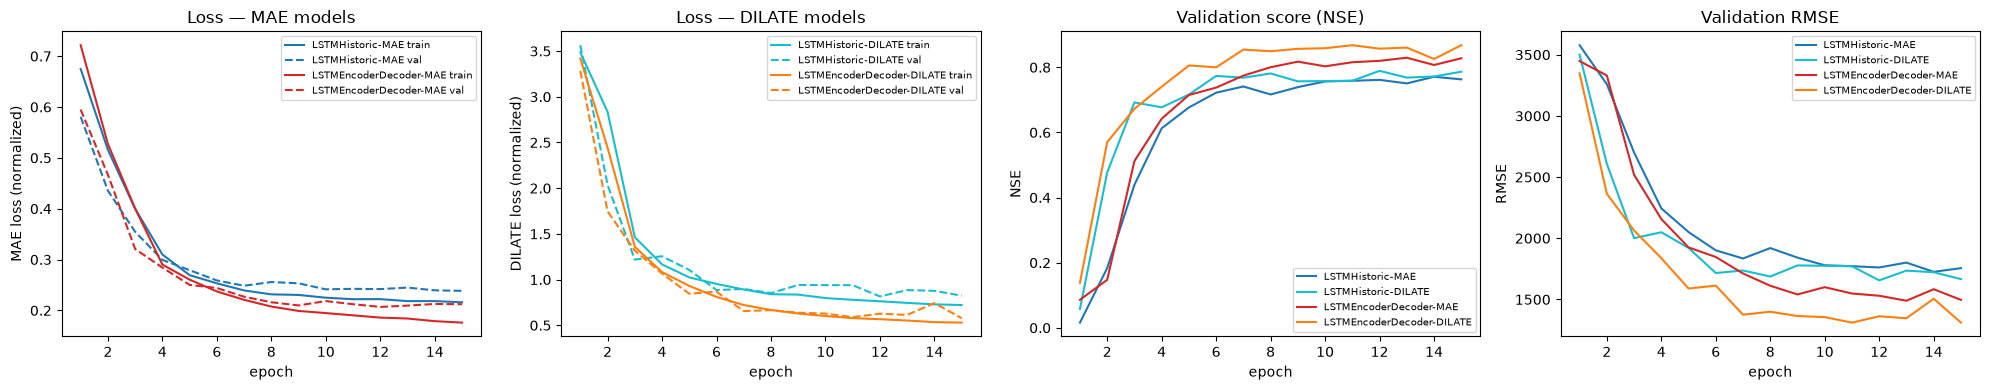

In [15]:
models = [
    ('LSTMHistoric-MAE', fc, 'tab:blue', 'mae'),
    ('LSTMHistoric-DILATE', fc3, 'tab:cyan', 'dilate'),
    ('LSTMEncoderDecoder-MAE', fc2, 'tab:red', 'mae'),
    ('LSTMEncoderDecoder-DILATE', fc4, 'tab:orange', 'dilate'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# loss is split by loss function — MAE-loss and DILATE-loss values live on different
# scales and aren't comparable on a shared axis
for label, m, color, loss_type in models:
    ep = np.arange(1, len(m.loss_log) + 1)
    ax = axes[0] if loss_type == 'mae' else axes[1]
    ax.plot(ep, m.loss_log, color=color, label=f'{label} train')
    ax.plot(ep, m.val_log_aggregated['mean']['loss'], color=color, linestyle='--', label=f'{label} val')
    axes[2].plot(ep, m.val_log_aggregated['mean']['val_score'], color=color, label=label)
    axes[3].plot(ep, m.val_log_aggregated['mean']['RMSE'], color=color, label=label)

axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MAE loss (normalized)')
axes[0].set_title('Loss — MAE models')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('epoch')
axes[1].set_ylabel('DILATE loss (normalized)')
axes[1].set_title('Loss — DILATE models')
axes[1].legend(fontsize=7)

axes[2].set_xlabel('epoch')
axes[2].set_ylabel('NSE')
axes[2].set_title('Validation score (NSE)')
axes[2].legend(fontsize=7)

axes[3].set_xlabel('epoch')
axes[3].set_ylabel('RMSE')
axes[3].set_title('Validation RMSE')
axes[3].legend(fontsize=7)

plt.tight_layout()
plt.show()

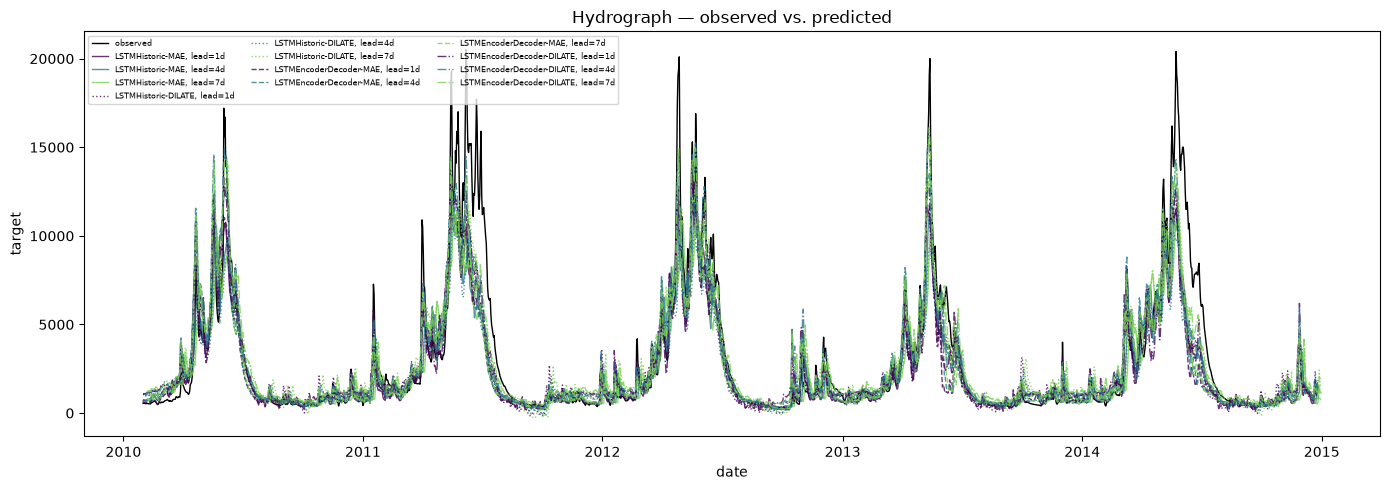

In [16]:
LEADS_TO_SHOW = [1, 4, 7]

# color encodes lead time, linestyle encodes model (architecture + loss)
model_preds = [
    ('LSTMHistoric-MAE', y_pred, t_values, '-'),
    ('LSTMHistoric-DILATE', y_pred3, t_values3, ':'),
    ('LSTMEncoderDecoder-MAE', y_pred2, t_values2, '--'),
    ('LSTMEncoderDecoder-DILATE', y_pred4, t_values4, '-.'),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lead_dates(1), y_true[:, 0], color='black', lw=1, label='observed')
colors = plt.cm.viridis(np.linspace(0, 0.8, len(LEADS_TO_SHOW)))
for label, y_p, t_vals, ls in model_preds:
    for lead, c in zip(LEADS_TO_SHOW, colors):
        dates = test_df.index[t_vals + SEQ_LEN + (lead - 1)]
        ax.plot(dates, y_p[:, lead - 1], color=c, lw=1, alpha=0.8, linestyle=ls, label=f'{label}, lead={lead}d')
ax.set_xlabel('date')
ax.set_ylabel(TARGET_COL)
ax.set_title('Hydrograph — observed vs. predicted')
ax.legend(ncol=3, fontsize=6)

plt.tight_layout()
plt.show()

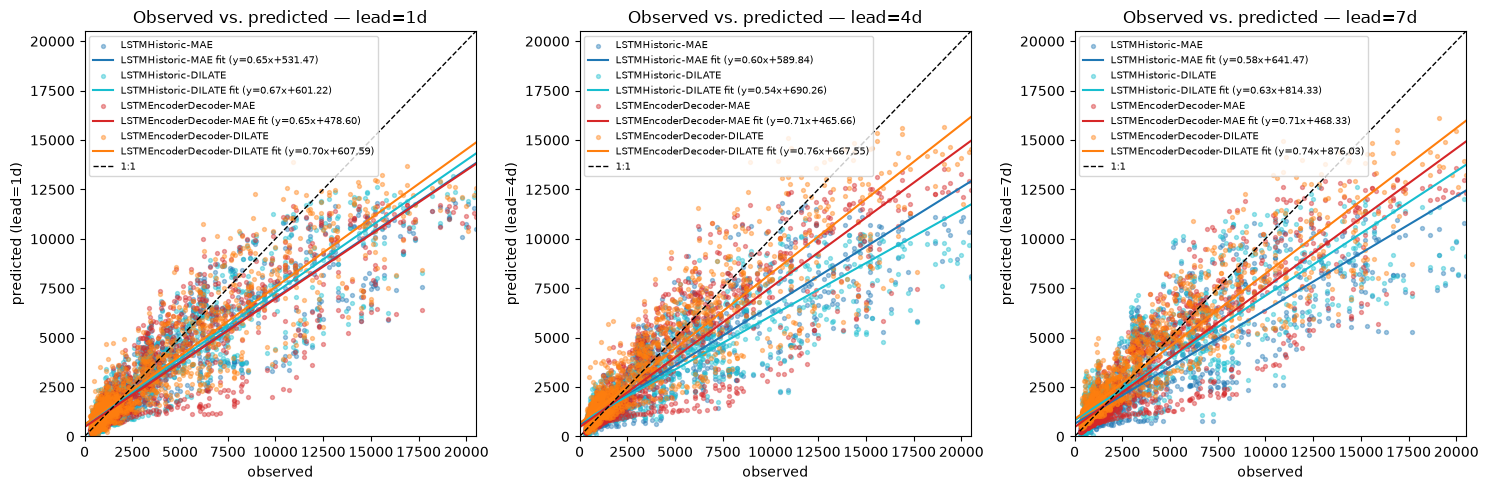

In [17]:
LEADS_TO_SHOW = [1, 4, 7]

model_preds = [
    ('LSTMHistoric-MAE', y_true, y_pred, 'tab:blue'),
    ('LSTMHistoric-DILATE', y_true3, y_pred3, 'tab:cyan'),
    ('LSTMEncoderDecoder-MAE', y_true2, y_pred2, 'tab:red'),
    ('LSTMEncoderDecoder-DILATE', y_true4, y_pred4, 'tab:orange'),
]

fig, axes = plt.subplots(1, len(LEADS_TO_SHOW), figsize=(5 * len(LEADS_TO_SHOW), 5))
lims = [0, np.nanmax([np.nanmax(yt) for _, yt, _, _ in model_preds] + [np.nanmax(yp) for _, _, yp, _ in model_preds])]

for ax, lead in zip(axes, LEADS_TO_SHOW):
    for label, yt, yp, color in model_preds:
        x = yt[:, lead - 1]
        y = yp[:, lead - 1]
        ax.scatter(x, y, s=8, alpha=0.4, color=color, label=label)

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() > 1:
            slope, intercept = np.polyfit(x[mask], y[mask], 1)
            xs = np.array(lims)
            ax.plot(xs, slope * xs + intercept, color=color, lw=1.5,
                    label=f'{label} fit (y={slope:.2f}x+{intercept:.2f})')

    ax.plot(lims, lims, color='black', lw=1, linestyle='--', label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('observed')
    ax.set_ylabel(f'predicted (lead={lead}d)')
    ax.set_title(f'Observed vs. predicted — lead={lead}d')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

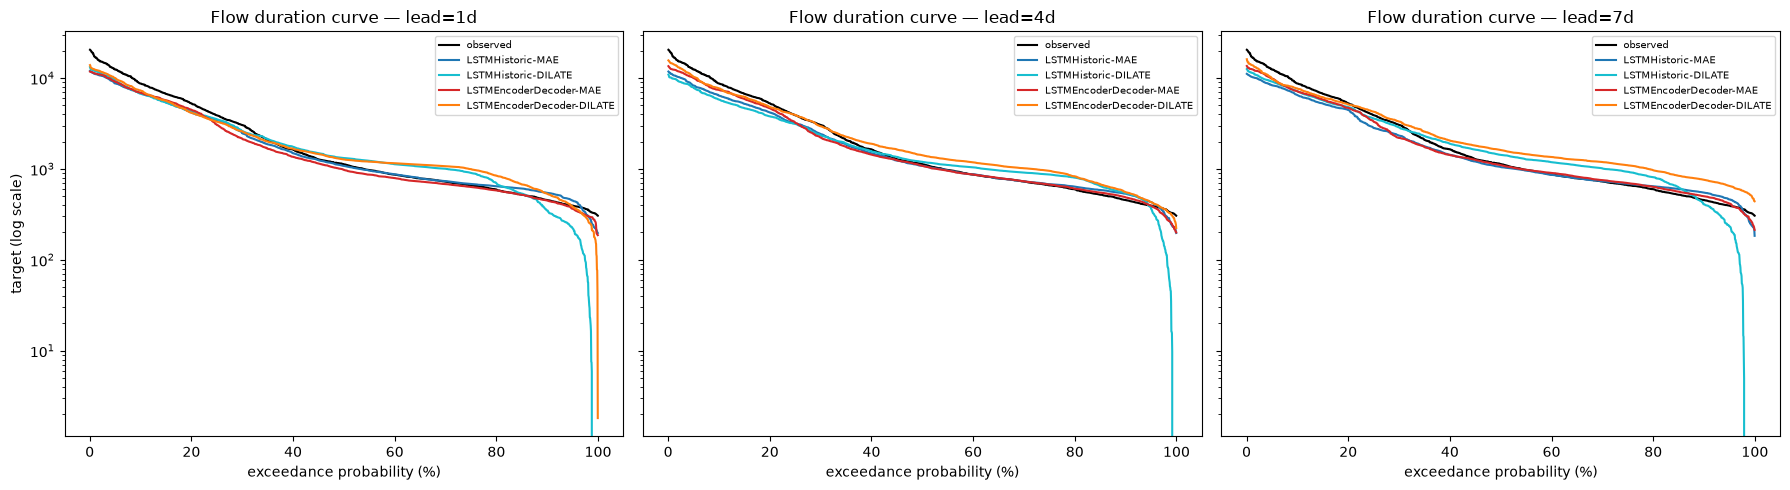

In [18]:
LEADS_TO_SHOW = [1, 4, 7]

def flow_duration_curve(values):
    values = values[~np.isnan(values)]
    sorted_vals = np.sort(values)[::-1]
    exceedance = np.arange(1, len(sorted_vals) + 1) / (len(sorted_vals) + 1) * 100
    return exceedance, sorted_vals

model_preds = [
    ('LSTMHistoric-MAE', y_pred, 'tab:blue'),
    ('LSTMHistoric-DILATE', y_pred3, 'tab:cyan'),
    ('LSTMEncoderDecoder-MAE', y_pred2, 'tab:red'),
    ('LSTMEncoderDecoder-DILATE', y_pred4, 'tab:orange'),
]

fig, axes = plt.subplots(1, len(LEADS_TO_SHOW), figsize=(6 * len(LEADS_TO_SHOW), 5), sharey=True)

for ax, lead in zip(axes, LEADS_TO_SHOW):
    exc_obs, sorted_obs = flow_duration_curve(y_true[:, lead - 1])
    ax.plot(exc_obs, sorted_obs, label='observed', color='black')
    for label, yp, color in model_preds:
        exc_pred, sorted_pred = flow_duration_curve(yp[:, lead - 1])
        ax.plot(exc_pred, sorted_pred, label=label, color=color)
    ax.set_yscale('log')
    ax.set_xlabel('exceedance probability (%)')
    ax.set_title(f'Flow duration curve — lead={lead}d')
    ax.legend(fontsize=7)

axes[0].set_ylabel(f'{TARGET_COL} (log scale)')
plt.tight_layout()
plt.show()

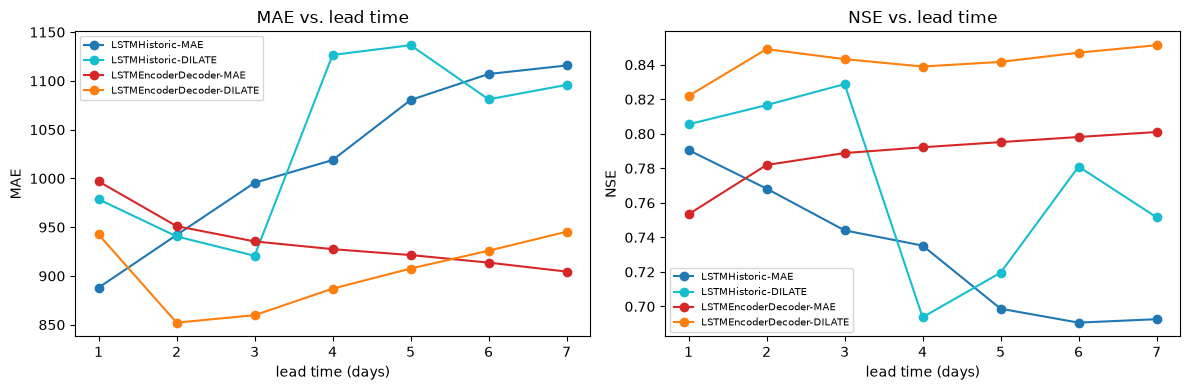

In [19]:
from src.utils.scores_and_losses import NSE

_nse_metric = NSE()

def nse(obs, pred):
    mask = ~np.isnan(obs) & ~np.isnan(pred)
    return _nse_metric(torch.tensor(pred[mask])[:, None], torch.tensor(obs[mask])[:, None]).item()

leads = np.arange(1, HORIZON + 1)
model_preds = [
    ('LSTMHistoric-MAE', y_true, y_pred, 'tab:blue'),
    ('LSTMHistoric-DILATE', y_true3, y_pred3, 'tab:cyan'),
    ('LSTMEncoderDecoder-MAE', y_true2, y_pred2, 'tab:red'),
    ('LSTMEncoderDecoder-DILATE', y_true4, y_pred4, 'tab:orange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, yt, yp, color in model_preds:
    mae_per_lead = [np.nanmean(np.abs(yt[:, i] - yp[:, i])) for i in range(HORIZON)]
    nse_per_lead = [nse(yt[:, i], yp[:, i]) for i in range(HORIZON)]
    axes[0].plot(leads, mae_per_lead, marker='o', color=color, label=label)
    axes[1].plot(leads, nse_per_lead, marker='o', color=color, label=label)

axes[0].set_xlabel('lead time (days)')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs. lead time')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('lead time (days)')
axes[1].set_ylabel('NSE')
axes[1].set_title('NSE vs. lead time')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()
